<a href="https://colab.research.google.com/github/Luisao2007/met-quant-trabalho/blob/main/notebooks/ap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/unifor-logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

Lattes: http://lattes.cnpq.br/5738786447903616 |
GitHub: https://github.com/carubbi/

[Unifor.br](https://unifor.br/) | [Instagram](https://www.instagram.com/uniforcomunica/?hl=pt-br) | [Facebook](https://www.facebook.com/uniforoficial/) | [Twitter](https://www.facebook.com/uniforoficial/)  | [LinkedIn](https://www.linkedin.com/school/university-of-fortaleza/?originalSubdomain=pt) | [TV Unifor](https://www.unifor.br/tv-unifor) | [G1/Ensinando e Aprendendo](https://g1.globo.com/ce/ceara/especial-publicitario/unifor/ensinando-e-aprendendo/)

# AP1 — Análise exploratória do preço de venda de imóveis residenciais


## 1. Importação do dado bruto

###Caminho
O caminho que ele vai percorrer para buscar o banco de dados. Neste caso, ele vai buscar direto no meu GitHub.

In [2]:
url = "https://raw.githubusercontent.com/Luisao2007/met-quant-trabalho/refs/heads/main/data/raw/AmesHousing.txt"

### Procedimento de leitura
**Importante:** O arquivo está sendo lido assim para manter os valores NA, como em Alley por exemplo, ao invés de serem interpretados como NaN.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definindo a quantidade máximas de colunas como infinito e de linhas como 100
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


df_raw = pd.read_csv(url, sep='\t', keep_default_na=False)

Copiando o arquivo para não alterar o data set bruto

In [4]:
imoveis = df_raw.copy()

## Conversões de valores

Para tratar apenas as colunas completas e corretas, precisamos corrigir alguns aspectos:

In [5]:
# Só converte para numérico as colunas em que os valores não vazios sejam números
for col in imoveis.columns:
    naoVazio = imoveis[col].ne("")
    colunaConvertida = pd.to_numeric(imoveis[col], errors="coerce")
    if naoVazio.any() and colunaConvertida[naoVazio].notna().all():
        imoveis[col] = colunaConvertida

# Caso esteja vazio, ele substitui por NaN na tabela
imoveis_faltantes = imoveis.replace("", np.nan)

## 2. Estrutura, unidade de análise e rastreabilidade

O dataset possui **2.930 observações e 82 variáveis**. Cada linha representa uma propriedade residencial registrada em uma venda.

As variáveis mantêm seus nomes originais no DataFrame principal.

In [6]:
print("Dimensões: " + str(imoveis.shape))

display(imoveis.head())
display(imoveis.tail())

Dimensões: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,NA,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,6,6,1984,1984,Gable,CompShg,HdBoard,HdBoard,None,0.0,TA,TA,CBlock,TA,TA,Av,GLQ,819.0,Unf,0.0,184.0,1003.0,GasA,TA,Y,SBrkr,1003,0,0,1003,1.0,0.0,1,0,3,1,TA,6,Typ,0,NA,Detchd,1984.0,Unf,2.0,588.0,TA,TA,Y,120,0,0,0,0,0,NA,GdPrv,NA,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NA,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1983,1983,Gable,CompShg,HdBoard,HdBoard,None,0.0,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0,ALQ,324.0,239.0,864.0,GasA,TA,Y,SBrkr,902,0,0,902,1.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1983.0,Unf,2.0,484.0,TA,TA,Y,164,0,0,0,0,0,NA,MnPrv,NA,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,None,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NA,NA,NaN,NA,0.0,0.0,NA,NA,Y,80,32,0,0,0,0,NA,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NA,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1974,1975,Gable,CompShg,HdBoard,HdBoard,None,0.0,TA,TA,CBlock,Gd,TA,Av,ALQ,1071.0,LwQ,123.0,195.0,1389.0,GasA,Gd,Y,SBrkr,1389,0,0,1389,1.0,0.0,1,0,2,1,TA,6,Typ,1,TA,Attchd,1975.0,RFn,2.0,418.0,TA,TA,Y,240,38,0,0,0,0,NA,NA,NA,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NA,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NA,NA,NA,0,11,2006,WD,Normal,188000


Para facilitar a leitura, criamos uma função que permite identificar e normalizar os nomes:

In [7]:
import re

def normalizar(nome):
  nomeOriginal = nome.strip().lower()
  nomeMaiusculo = re.sub(r"[^a-z0-9]+", "_", nomeOriginal)
  nomeCorreto = re.sub(r"_+", "_", nomeMaiusculo).strip("_")
  return nomeCorreto


A seguir, comparamos os nomes antigos com os novos:

In [8]:
import re

def normalizar(nome):
  nomeOriginal = nome.strip().lower()
  nomeMaiusculo = re.sub(r"[^a-z0-9]+", "_", nomeOriginal)
  nomeCorreto = re.sub(r"_+", "_", nomeMaiusculo).strip("_")
  return nomeCorreto

comparação = pd.DataFrame({
    "nome_original": imoveis.columns,
    "nome_novo": [normalizar(nome) for nome in imoveis.columns]
})

display(comparação)

,nome_original,nome_novo
0,Order,order
1,PID,pid
2,MS SubClass,ms_subclass
3,MS Zoning,ms_zoning
4,Lot Frontage,lot_frontage
5,Lot Area,lot_area
6,Street,street
7,Alley,alley
8,Lot Shape,lot_shape
9,Land Contour,land_contour


### Variáveis centrais da AP1

| Nome legível | Nome original | Tipo conceitual |
|---|---|---|
| Preço de venda | `SalePrice` | Quantitativa contínua |
| Área construída acima do solo | `Gr Liv Area` | Quantitativa contínua |
| Ano da venda | `Yr Sold` | Temporal discreta |
| Mês da venda | `Mo Sold` | Temporal discreta |
| Qualidade externa | `Exter Qual` | Qualitativa ordinal |
| Ano de construção | `Year Built` | Temporal/discreta |
| Ano de reforma ou adição | `Year Remod/Add` | Temporal/discreta |
| Número de lareiras | `Fireplaces` | Quantitativa discreta |
| Área de revestimento de alvenaria | `Mas Vnr Area` | Quantitativa contínua |

Na documentação, `Exter Qual` é ordinal e possui cinco níveis: `Ex` (Excellent), `Gd` (Good), `TA` (Average/Typical), `Fa` (Fair) e `Po` (Poor).


## 3. Qualidade e preparação dos dados

A preparação segue quatro princípios:

1. preservar `df_raw` sem alterações;
2. converter apenas variáveis claramente numéricas;
3. tratar células vazias como ausências;
4. não converter automaticamente códigos semânticos como `NA` em ausência.

Essa última decisão é importante no Ames Housing: a documentação utiliza `NA` como categoria válida em algumas variáveis, por exemplo `Bsmt Qual = NA` significa ausência de porão. Portanto, uma substituição global de `NA -> NaN` poderia destruir informação.


In [9]:
# Resumo de tipos, ausências e duplicatas
quality = pd.DataFrame({
    "tipo": imoveis.dtypes.astype(str),
    "n_ausentes": imoveis_faltantes.isna().sum(),
    "pct_ausentes": (imoveis_faltantes.isna().mean() * 100).round(2)
})

quality["n_unicos"] = imoveis.nunique(dropna=True).values
quality


,tipo,n_ausentes,pct_ausentes,n_unicos
Order,int64,0,0.00,2930
PID,int64,0,0.00,2930
MS SubClass,int64,0,0.00,16
MS Zoning,object,0,0.00,7
Lot Frontage,float64,490,16.72,128
Lot Area,int64,0,0.00,1960
Street,object,0,0.00,2
Alley,object,0,0.00,3
Lot Shape,object,0,0.00,4
Land Contour,object,0,0.00,4


In [11]:
# Duplicatas
print("Linhas duplicadas:", int(imoveis.duplicated().sum()))

# Variáveis solicitadas para inspeção
inspect_cols = ["Fireplaces", "Mas Vnr Area", "Year Remod/Add", "Year Built"]

inspection = pd.DataFrame({
    "variavel": inspect_cols,
    "tipo": [imoveis[c].dtype for c in inspect_cols],
    "ausentes": [imoveis_faltantes[c].isna().sum() for c in inspect_cols],
    "min": [imoveis[c].min() for c in inspect_cols],
    "mediana": [imoveis[c].median() for c in inspect_cols],
    "max": [imoveis[c].max() for c in inspect_cols]
})

inspection


Linhas duplicadas: 0


,variavel,tipo,ausentes,min,mediana,max
0,Fireplaces,int64,0,0.0,1.0,4.0
1,Mas Vnr Area,float64,23,0.0,0.0,1600.0
2,Year Remod/Add,int64,0,1950.0,1993.0,2010.0
3,Year Built,int64,0,1872.0,1973.0,2010.0


### Observação sobre `Mas Vnr Area`

As 23 células vazias de `Mas Vnr Area` são mantidas como ausentes nesta AP1. **Não** serão automaticamente transformadas em zero apenas porque algumas casas não possuem revestimento de alvenaria. A interpretação deve considerar conjuntamente `Mas Vnr Type` e a documentação da base.

Essa decisão evita afirmar, sem evidência, que toda ausência de preenchimento representa “sem revestimento”.


## 5. Análise univariada

As variáveis quantitativas principais são `SalePrice` e `Gr Liv Area`. Para ambas, serão apresentados medidas de posição, dispersão e forma.


In [12]:
# Estatísticas descritivas para SalePrice e Gr Liv Area
univariadas = pd.DataFrame({
    "SalePrice": imoveis["SalePrice"].describe(),
    "Gr Liv Area": imoveis["Gr Liv Area"].describe()
}).T

univariadas["amplitude"] = univariadas["max"] - univariadas["min"]
univariadas["assimetria"] = [
    imoveis["SalePrice"].skew(),
    imoveis["Gr Liv Area"].skew()
]

univariadas = univariadas[
    ["count", "mean", "50%", "std", "min", "25%", "75%", "max",
     "amplitude", "assimetria"]
].rename(columns={"50%": "mediana"})

univariadas


,count,mean,mediana,std,min,25%,75%,max,amplitude,assimetria
SalePrice,2930.0,180796.060068,160000.0,79886.692357,12789.0,129500.0,213500.00,755000.0,742211.0,1.74350
Gr Liv Area,2930.0,1499.690444,1442.0,505.508887,334.0,1126.0,1742.75,5642.0,5308.0,1.27411


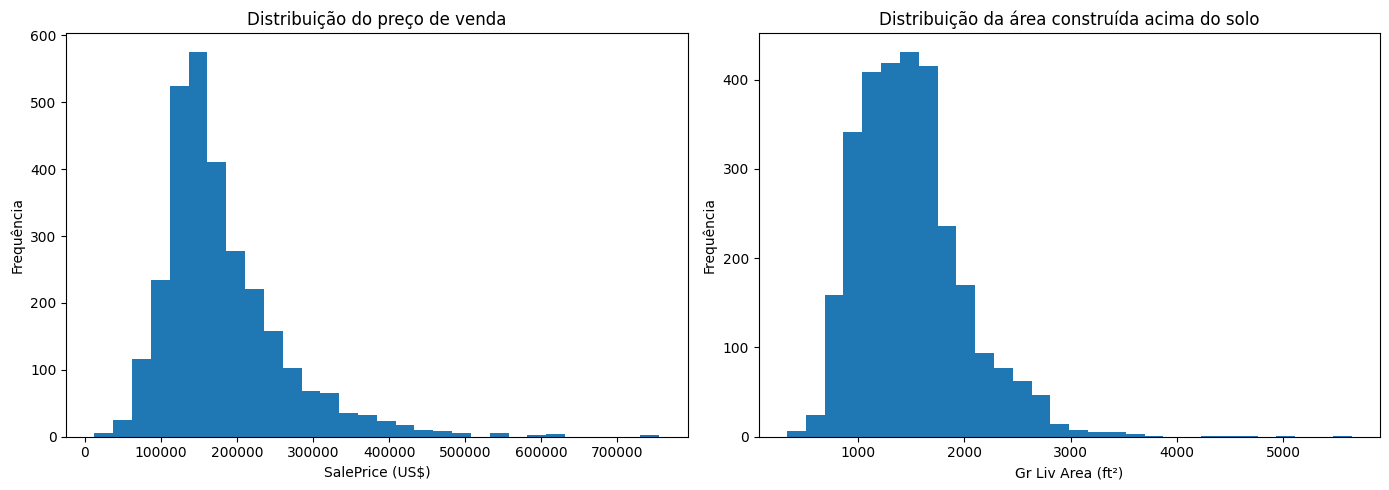

In [13]:
# Histogramas — uma figura com dois painéis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(imoveis["SalePrice"], bins=30)
axes[0].set_title("Distribuição do preço de venda")
axes[0].set_xlabel("SalePrice (US$)")
axes[0].set_ylabel("Frequência")

axes[1].hist(imoveis["Gr Liv Area"], bins=30)
axes[1].set_title("Distribuição da área construída acima do solo")
axes[1].set_xlabel("Gr Liv Area (ft²)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


### Característica qualitativa B — `Exter Qual`

`Exter Qual` é uma variável **ordinal**: existe uma ordem natural entre seus níveis de qualidade. A documentação define:

- `Ex` = Excellent
- `Gd` = Good
- `TA` = Average/Typical
- `Fa` = Fair
- `Po` = Poor

No arquivo analisado, as categorias observadas são essas quatro? Não: o conjunto contém **cinco níveis documentados**, e a frequência de cada um será apresentada diretamente pela tabela abaixo.


In [14]:
# Frequência absoluta e relativa de Exter Qual
exter_freq = (
    imoveis["Exter Qual"]
    .value_counts(dropna=False)
    .reindex(["Po", "Fa", "TA", "Gd", "Ex"])
    .rename_axis("Exter Qual")
    .reset_index(name="frequencia_absoluta")
)

exter_freq["frequencia_relativa_%"] = (
    exter_freq["frequencia_absoluta"] / len(imoveis) * 100
).round(2)

exter_freq["categoria_legivel"] = exter_freq["Exter Qual"].map({
    "Po": "Péssima (Po)",
    "Fa": "Ruim (Fa)",
    "TA": "Média/Típica (TA)",
    "Gd": "Boa (Gd)",
    "Ex": "Excelente (Ex)"
})

exter_freq


,Exter Qual,frequencia_absoluta,frequencia_relativa_%,categoria_legivel
0,Po,NaN,NaN,Péssima (Po)
1,Fa,35.0,1.19,Ruim (Fa)
2,TA,1799.0,61.40,Média/Típica (TA)
3,Gd,989.0,33.75,Boa (Gd)
4,Ex,107.0,3.65,Excelente (Ex)


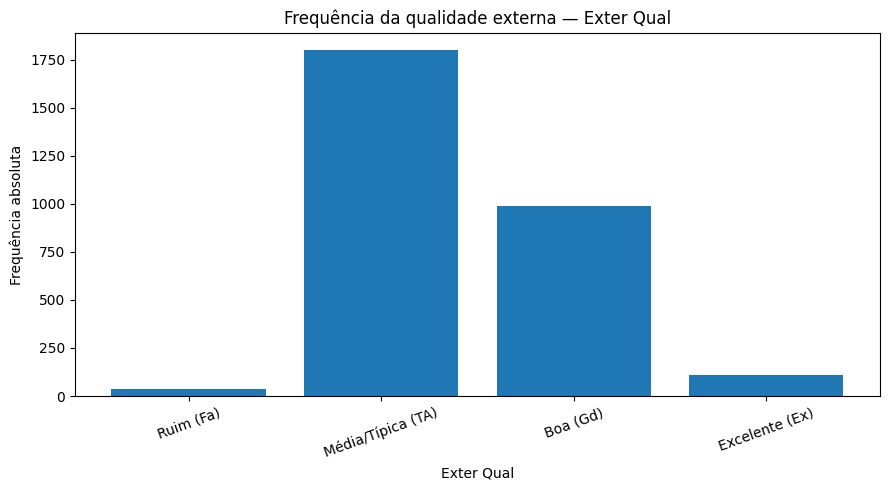

In [15]:
# Gráfico de barras da característica B
plot_data = exter_freq.dropna(subset=["Exter Qual"])

plt.figure(figsize=(9, 5))
plt.bar(plot_data["categoria_legivel"], plot_data["frequencia_absoluta"])
plt.title("Frequência da qualidade externa — Exter Qual")
plt.xlabel("Exter Qual")
plt.ylabel("Frequência absoluta")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 6. Valores atípicos — critério de Tukey

Serão utilizados os limites:

- **LI = Q1 − 1,5 × IQR**
- **LS = Q3 + 1,5 × IQR**

O critério identifica observações potencialmente atípicas; ele **não determina sozinho que uma observação é erro**.


In [16]:
def tukey_table(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = (series < lower) | (series > upper)
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LI": lower,
        "LS": upper,
        "n_atipicos": int(flagged.sum())
    }

outlier_table = pd.DataFrame({
    "SalePrice": tukey_table(imoveis["SalePrice"]),
    "Gr Liv Area": tukey_table(imoveis["Gr Liv Area"])
}).T

outlier_table


,Q1,Q3,IQR,LI,LS,n_atipicos
SalePrice,129500.0,213500.00,84000.00,3500.000,339500.000,137.0
Gr Liv Area,1126.0,1742.75,616.75,200.875,2667.875,75.0


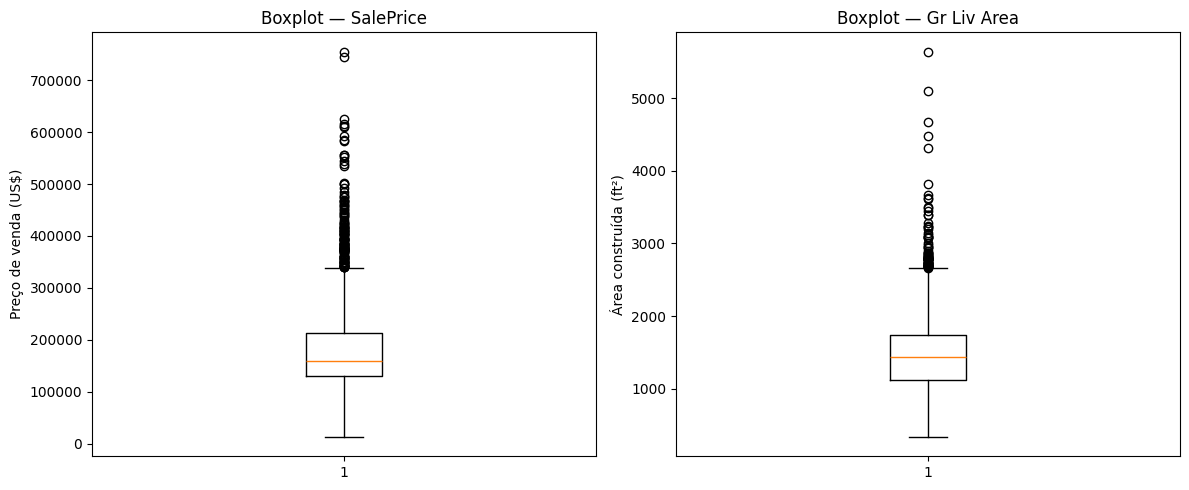

In [17]:
# Boxplots de SalePrice e Gr Liv Area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(imoveis["SalePrice"])
axes[0].set_title("Boxplot — SalePrice")
axes[0].set_ylabel("Preço de venda (US$)")

axes[1].boxplot(imoveis["Gr Liv Area"])
axes[1].set_title("Boxplot — Gr Liv Area")
axes[1].set_ylabel("Área construída (ft²)")

plt.tight_layout()
plt.show()


In [18]:
# Observações sinalizadas pelo critério de Tukey em Gr Liv Area
gl_q1 = imoveis["Gr Liv Area"].quantile(.25)
gl_q3 = imoveis["Gr Liv Area"].quantile(.75)
gl_iqr = gl_q3 - gl_q1
gl_lo = gl_q1 - 1.5 * gl_iqr
gl_hi = gl_q3 + 1.5 * gl_iqr

gl_flagged = imoveis.loc[
    (imoveis["Gr Liv Area"] < gl_lo) | (imoveis["Gr Liv Area"] > gl_hi),
    ["Order", "PID", "SalePrice", "Gr Liv Area", "Exter Qual"]
].sort_values("Gr Liv Area", ascending=False)

gl_flagged


,Order,PID,SalePrice,Gr Liv Area,Exter Qual
1498,1499,908154235,160000,5642,Ex
2180,2181,908154195,183850,5095,Ex
2181,2182,908154205,184750,4676,Ex
1760,1761,528320050,745000,4476,Gd
1767,1768,528351010,755000,4316,Ex
1497,1498,908154080,284700,3820,TA
2737,2738,905427030,415000,3672,TA
2445,2446,528320060,625000,3627,Gd
2666,2667,902400110,475000,3608,Gd
2450,2451,528360050,584500,3500,Gd


### Decisão sobre os valores atípicos

Nesta AP1, os valores atípicos **não são removidos automaticamente**.

Para `SalePrice`, o critério de Tukey sinaliza valores altos, mas preços elevados podem representar imóveis reais e, portanto, não constituem por si só erro de registro.

Para `Gr Liv Area`, existem observações extremamente grandes em relação ao restante da amostra. Como a análise é exploratória, a decisão principal será **manter os registros na base original e na análise principal**, sinalizando-os como potenciais observações influentes. Isso preserva a rastreabilidade e evita transformar um critério estatístico em uma regra automática de exclusão.

A sensibilidade será demonstrada comparando a correlação de Pearson com e sem os registros sinalizados em `Gr Liv Area`.


## 7. Análise bivariada

### 7.1 `SalePrice` × `Yr Sold`

A análise anual utiliza a **mediana do preço de venda**, acompanhada da quantidade de observações. A linha representa a mediana de cada ano; ela não conecta preços individuais.

A interpretação deve ser descritiva: diferenças entre anos podem refletir composição da amostra, condições de mercado, inflação e outras características. O gráfico não deve ser interpretado como evidência de causalidade.


In [19]:
year_summary = (
    imoveis.groupby("Yr Sold", as_index=False)
      .agg(
          n=("SalePrice", "size"),
          mediana=("SalePrice", "median")
      )
      .sort_values("Yr Sold")
)

year_summary


,Yr Sold,n,mediana
0,2006,625,159500.0
1,2007,694,165125.0
2,2008,622,161000.0
3,2009,648,160850.0
4,2010,341,155000.0


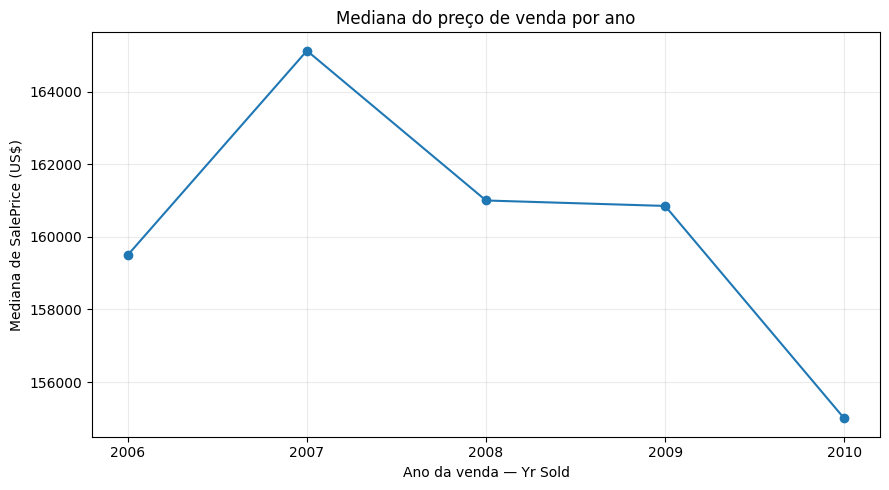

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(year_summary["Yr Sold"], year_summary["mediana"], marker="o")
plt.title("Mediana do preço de venda por ano")
plt.xlabel("Ano da venda — Yr Sold")
plt.ylabel("Mediana de SalePrice (US$)")
plt.xticks(year_summary["Yr Sold"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 7.2 `SalePrice` × `Gr Liv Area`

O gráfico de dispersão permite observar direção, forma, concentração e possíveis grupos/outliers. A correlação de Pearson será calculada, lembrando que **correlação não implica causalidade**.


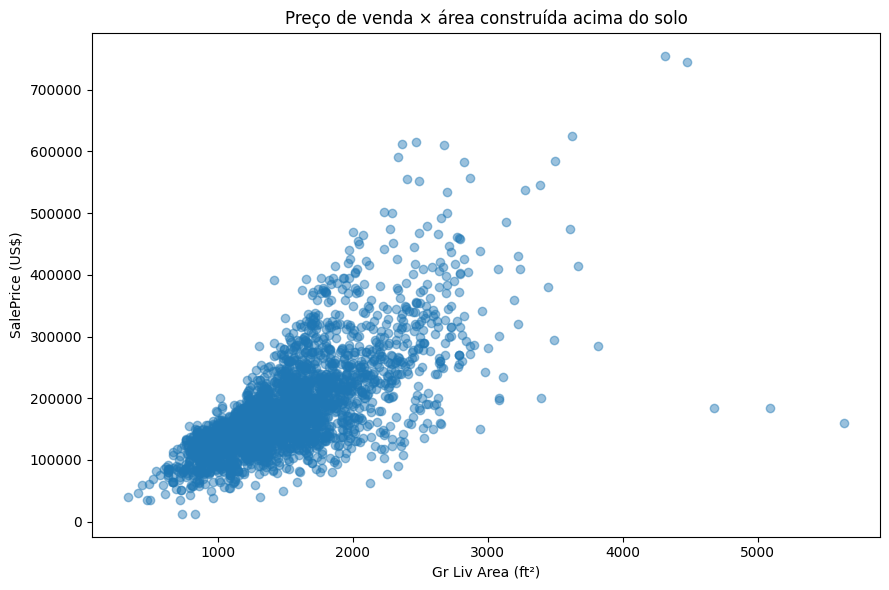

Correlação de Pearson (amostra completa): 0.7068


In [21]:
pearson_all = imoveis[["SalePrice", "Gr Liv Area"]].corr(method="pearson").loc["SalePrice", "Gr Liv Area"]

plt.figure(figsize=(9, 6))
plt.scatter(imoveis["Gr Liv Area"], imoveis["SalePrice"], alpha=0.45)
plt.title("Preço de venda × área construída acima do solo")
plt.xlabel("Gr Liv Area (ft²)")
plt.ylabel("SalePrice (US$)")
plt.tight_layout()
plt.show()

print(f"Correlação de Pearson (amostra completa): {pearson_all:.4f}")


In [22]:
# Sensibilidade da correlação sem os registros sinalizados por Tukey em Gr Liv Area
mask_gl = ~((imoveis["Gr Liv Area"] < gl_lo) | (imoveis["Gr Liv Area"] > gl_hi))
pearson_without_flagged = imoveis.loc[mask_gl, ["SalePrice", "Gr Liv Area"]].corr().loc["SalePrice", "Gr Liv Area"]

comparison_corr = pd.DataFrame({
    "amostra": ["Completa", "Sem atípicos de Gr Liv Area"],
    "n": [len(imoveis), int(mask_gl.sum())],
    "pearson": [pearson_all, pearson_without_flagged]
})

comparison_corr


,amostra,n,pearson
0,Completa,2930,0.70678
1,Sem atípicos de Gr Liv Area,2855,0.68347


### 7.3 `SalePrice` × `Exter Qual`

Como `Exter Qual` é ordinal, as categorias serão apresentadas na ordem de qualidade: `Po`, `Fa`, `TA`, `Gd`, `Ex`.

Para cada categoria, serão apresentados número de observações, mediana, primeiro quartil, terceiro quartil e IQR.


In [23]:
exter_price = (
    imoveis.groupby("Exter Qual", observed=True)["SalePrice"]
      .agg(
          n="size",
          mediana="median",
          Q1=lambda x: x.quantile(.25),
          Q3=lambda x: x.quantile(.75)
      )
      .reindex(["Po", "Fa", "TA", "Gd", "Ex"])
)

exter_price["IQR"] = exter_price["Q3"] - exter_price["Q1"]
exter_price = exter_price.reset_index()

exter_price["categoria_legivel"] = exter_price["Exter Qual"].map({
    "Po": "Péssima (Po)",
    "Fa": "Ruim (Fa)",
    "TA": "Média/Típica (TA)",
    "Gd": "Boa (Gd)",
    "Ex": "Excelente (Ex)"
})

exter_price


,Exter Qual,n,mediana,Q1,Q3,IQR,categoria_legivel
0,Po,NaN,NaN,NaN,NaN,NaN,Péssima (Po)
1,Fa,35.0,85000.0,59500.0,115750.0,56250.0,Ruim (Fa)
2,TA,1799.0,139000.0,119000.0,163000.0,44000.0,Média/Típica (TA)
3,Gd,989.0,219500.0,183000.0,267300.0,84300.0,Boa (Gd)
4,Ex,107.0,370967.0,317250.0,442520.5,125270.5,Excelente (Ex)


In [ ]:
# Boxplot de SalePrice por Exter Qual
ordered = ["Po", "Fa", "TA", "Gd", "Ex"]
box_data = [imoveis.loc[imoveis["Exter Qual"] == cat, "SalePrice"] for cat in ordered]

plt.figure(figsize=(11, 6))
plt.boxplot(box_data, labels=[exter_labels[c] for c in ordered])
plt.title("Distribuição de SalePrice por qualidade externa — Exter Qual")
plt.xlabel("Qualidade externa")
plt.ylabel("SalePrice (US$)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 8. Interpretação sintética dos resultados

A análise deve ser lida como descrição da amostra, e não como demonstração de causalidade.

- `SalePrice` apresenta variabilidade elevada, com valores muito acima do centro da distribuição; o critério de Tukey identifica **137 observações** como potenciais atípicas.
- `Gr Liv Area` também apresenta valores extremos; o critério de Tukey identifica **75 observações** potenciais.
- `Exter Qual` possui cinco níveis documentados (`Po`, `Fa`, `TA`, `Gd`, `Ex`) e, nesta amostra, as categorias mais frequentes são observadas diretamente na tabela de frequências.
- A relação entre `SalePrice` e `Gr Liv Area` deve ser interpretada conjuntamente com a correlação e o gráfico de dispersão, considerando a influência dos valores extremos.
- A comparação entre `SalePrice` e `Exter Qual` descreve diferenças de posição e dispersão entre categorias; ela não demonstra que a qualidade externa, isoladamente, cause diferenças de preço.
- A mediana anual de `SalePrice` descreve a composição observada por ano, mas não deve ser interpretada como uma série temporal causal.


## 9. Exportação da base processada

A base bruta permanece em `data/raw/AmesHousing.txt`.

A base utilizada para análises/processamento será exportada para:

```text
data/processed/AmesHousing.csv
```

Os nomes das colunas serão padronizados em `snake_case`. A tabela `mapping` registra a correspondência entre cada nome original e o nome utilizado.


In [25]:
# Exportação da base processada
import os
imoveis_processado = imoveis.copy()
imoveis_processado.columns = [normalizar(c) for c in imoveis_processado.columns]

os.makedirs("data/processed", exist_ok=True)
caminho_processado = "data/processed/AmesHousing.csv"
imoveis_processado.to_csv(caminho_processado, index=False, encoding="utf-8")

print("Arquivo salvo em:", caminho_processado)
print("Dimensões:", imoveis_processado.shape)
display(imoveis_processado.head())


Arquivo salvo em: data/processed/AmesHousing.csv
Dimensões: (2930, 82)


,order,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,land_slope,neighborhood,condition_1,condition_2,bldg_type,house_style,overall_qual,overall_cond,year_built,year_remod_add,roof_style,roof_matl,exterior_1st,exterior_2nd,mas_vnr_type,mas_vnr_area,exter_qual,exter_cond,foundation,bsmt_qual,bsmt_cond,bsmt_exposure,bsmtfin_type_1,bsmtfin_sf_1,bsmtfin_type_2,bsmtfin_sf_2,bsmt_unf_sf,total_bsmt_sf,heating,heating_qc,central_air,electrical,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,kitchen_qual,totrms_abvgrd,functional,fireplaces,fireplace_qu,garage_type,garage_yr_blt,garage_finish,garage_cars,garage_area,garage_qual,garage_cond,paved_drive,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


## Declaração de uso de inteligência artificial

Este grupo usou o ChatGPT para fornecer esta apresentação da AP1 e a extração do link para o dataset original da Ames Housing. O github e alguns detalhes adicionados a esse notebook foram feitos a mão.